# Proyecto Final

## Pipline del Notebook

1. EDA
* distribuciones (log)
* outliers
* correlaciones (Spearman)
2. Feature engineering
* ratios
* logs
* flags
3. Tests
* Mann-Whitney → corto vs largo
* Kruskal → género
* Spearman → relaciones
4. Modelo
* regresión (explicativo)
* clasificación (is_hit)

## Información del proyecto

### Datos descargados

**Desde diferentes pruebas de APi request trabajadas en distintas versiones del proyecto:**
- `backup_tracks.csv` — tracks enriquecidos via `track.getInfo` (nombre, artista, duración en ms, tag, playcount, listeners, published)
- `lastfm_dataset.csv` — tracks del pipeline multi-endpoint (aporta: country, genre_tag, rank_global, rank_by_country)
- `tags_dataset.csv` código añadido via método `track.getInfo` después de crear `backup_tracks.csv` 

### DataFrames:

| Nombre      | Significado               |
| ----------- | ------------------------- |
| df          | raw data                  |
| df_tracks   | datos de tracks |
| df_raw    | datos descargados             |
| df_clean    | datos limpios             |
| df_analysis | datos para análisis       |
| df_enriched | datos con features nuevas |

* Aclaracioens en de las variables:

| Variable    | Qué mide                         |
| ----------- | -------------------------------- |
| `playcount` | reproducciones de una canción    |
| `listeners` | oyentes de una canción           |
| `count`     | cuántas veces se usa un género   |
| `reach`     | cuántos usuarios usan ese género |


* tag_list[ ] = Lista de tracks por género (tag).
* tracks [ ] = Lista de tracks según tags encontrados.


### Endpoints

| Endpoint | Qué devuelve | Para qué lo usamos |
|---|---|---|
| `tag.getTopTags` | Tags globales con name, count, reach | Construir `df_tags` |
| `tag.getTopTracks` | Tracks por género | Construir `df_tracks` |
| `track.getInfo` | Metadata completa por mbid | Crea `backup_tracks.csv` |

---
## 1. Importaciones y configuración

In [1]:
import os
import ast
import time
import warnings
import pickle
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
# import statsmodels.api as sm

from scipy.stats import spearmanr, mannwhitneyu, kruskal
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, r2_score, mean_absolute_error

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 100


* os → trabajar con archivos/sistema(no lo estás usando aún ❗)
* time → pausas (útil para APIs → evitar rate limits)
* warnings → ocultar warnings molestos
* requests → hacer llamadas a la API
* numpy (np) → operaciones numéricas (NaN, arrays)
* pandas (pd) →  manipulación de datos
* matplotlib.pyplot → gráficos base
* mticker → formatear ejes
* seaborn → gráficos más bonitos

In [ ]:
import os

print("📍 Current working directory:")
print(os.getcwd())

print("\n📂 Archivos en este directorio:")
print(os.listdir())

print("\n📂 Archivos en data:")
print(os.listdir('data'))

print("\n📂 Archivos en data/processed:")
print(os.listdir('data/processed'))

---
## 2. Configuración API



### Peticiones 

> **CORRECCIÓN #1 — API sin validación:** el código original hacía `re.json()` sin comprobar `status_code`.  
> Si la API devuelve 403/429/500, `.json()` lanza excepción no controlada.  
> **Solución:** función `get_json()` centralizada con validación y `try/except`.

In [2]:
API_KEY = '63e059c3c912a3f642daf2372484d183'
BASE_URL = f'http://ws.audioscrobbler.com/2.0/?api_key={API_KEY}&'


# CORRECCIÓN #1: función centralizada con validación de status_code y control de errores
# def get_json(url):
#     """Petición GET con validación de status y manejo de errores de red."""
#     try:
#         time.sleep(0.5)  # delay para no superar rate limit (~4 req/s, límite = 5)
#         resp = requests.get(url, timeout=10)
#         if resp.status_code != 200:
#             print(f'  ⚠️  HTTP {resp.status_code} para: {url[:80]}')
#             return None
#         return resp.json()
#     except requests.exceptions.RequestException as e:
#         print(f'  ⚠️  Error de red: {e}')
#         return None

# print('✅ API configurada')

---
## 3. Extracción de datos y Construcción de `df_tracks`


> **CORRECCIÓN #2 — Tags solo guardaban `name`:** el código original solo extraía el nombre a una lista plana.  
> La API devuelve también `count` y `reach`, útiles para filtrar tags relevantes.  
> **Solución:** capturar los tres campos y construir `df_tags` como DataFrame enriquecido.

### 1. Get top tags → `df_tags`

In [3]:
re = requests.get(f'{BASE_URL}method=tag.getTopTags&format=json')

if re.status_code == 200:
    print('Petición correcta')
    re_json = re.json()
else:
    raise Exception(f"Error en la petición: {re.status_code}")

Petición correcta


In [4]:
re_json['toptags']['tag'][:10]

[{'name': 'rock', 'count': 4069820, 'reach': 402953},
 {'name': 'electronic', 'count': 2499435, 'reach': 262252},
 {'name': 'seen live', 'count': 2194840, 'reach': 82563},
 {'name': 'alternative', 'count': 2131119, 'reach': 267229},
 {'name': 'pop', 'count': 2083017, 'reach': 233796},
 {'name': 'indie', 'count': 2065556, 'reach': 260482},
 {'name': 'female vocalists', 'count': 1634638, 'reach': 169167},
 {'name': 'metal', 'count': 1305873, 'reach': 159033},
 {'name': 'alternative rock', 'count': 1230585, 'reach': 170276},
 {'name': 'jazz', 'count': 1196725, 'reach': 149998}]

In [5]:
tag_list = []
for i in re_json['toptags']['tag']:
  tag_list.append(i['name'])
len(tag_list)

50

In [6]:
raw_tags = re_json.get('toptags', {}).get('tag', []) if re_json else []
df_tags = pd.DataFrame([{'name' : t.get('name', np.nan),
     'count': int(t.get('count', np.nan)),
     'reach': int(t.get('reach', np.nan))}
    for t in raw_tags])

print(f'df_tags: {df_tags.shape[0]} tags')
df_tags.head(10)

df_tags: 50 tags


,name,count,reach
0,rock,4069820,402953
1,electronic,2499435,262252
2,seen live,2194840,82563
3,alternative,2131119,267229
4,pop,2083017,233796
5,indie,2065556,260482
6,female vocalists,1634638,169167
7,metal,1305873,159033
8,alternative rock,1230585,170276
9,jazz,1196725,149998


In [7]:

df_tags = pd.read_csv('../data/raw/tags_dataset.csv')


In [8]:
df_tags.info()

<class 'pandas.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   name    50 non-null     str  
 1   count   50 non-null     int64
 2   reach   50 non-null     int64
dtypes: int64(2), str(1)
memory usage: 1.3 KB


* Limpieza de la columna tag para poder importar correctamente count y reach data:

In [9]:
df_tags['count'].isnull().sum()

np.int64(0)

### 2. Get info → genera `backup_tracks.csv`

In [13]:
prueba = requests.get(f"{BASE_URL}method=track.getInfo&mbid={df_tracks['mbid'].iloc[0]}&format=json")
prueba_json = prueba.json()
prueba_json


{'track': {'name': 'The Chain',
  'mbid': '021c73b9-c6d5-41de-a852-8b990b7e24e7',
  'url': 'https://www.last.fm/music/Fleetwood+Mac/_/The+Chain',
  'duration': '269000',
  'streamable': {'#text': '0', 'fulltrack': '0'},
  'listeners': '624291',
  'playcount': '4516591',
  'artist': {'name': 'Fleetwood Mac',
   'mbid': 'bd13909f-1c29-4c27-a874-d4aaf27c5b1a',
   'url': 'https://www.last.fm/music/Fleetwood+Mac'},
  'album': {'artist': 'Fleetwood Mac',
   'title': 'Rumours',
   'url': 'https://www.last.fm/music/Fleetwood+Mac/Rumours',
   'image': [{'#text': 'https://lastfm.freetls.fastly.net/i/u/34s/349d64820e124b77cb5275ab03042693.png',
     'size': 'small'},
    {'#text': 'https://lastfm.freetls.fastly.net/i/u/64s/349d64820e124b77cb5275ab03042693.png',
     'size': 'medium'},
    {'#text': 'https://lastfm.freetls.fastly.net/i/u/174s/349d64820e124b77cb5275ab03042693.png',
     'size': 'large'},
    {'#text': 'https://lastfm.freetls.fastly.net/i/u/300x300/349d64820e124b77cb5275ab03042693.p

In [14]:
prueba_json.get('track')

{'name': 'The Chain',
 'mbid': '021c73b9-c6d5-41de-a852-8b990b7e24e7',
 'url': 'https://www.last.fm/music/Fleetwood+Mac/_/The+Chain',
 'duration': '269000',
 'streamable': {'#text': '0', 'fulltrack': '0'},
 'listeners': '624291',
 'playcount': '4516591',
 'artist': {'name': 'Fleetwood Mac',
  'mbid': 'bd13909f-1c29-4c27-a874-d4aaf27c5b1a',
  'url': 'https://www.last.fm/music/Fleetwood+Mac'},
 'album': {'artist': 'Fleetwood Mac',
  'title': 'Rumours',
  'url': 'https://www.last.fm/music/Fleetwood+Mac/Rumours',
  'image': [{'#text': 'https://lastfm.freetls.fastly.net/i/u/34s/349d64820e124b77cb5275ab03042693.png',
    'size': 'small'},
   {'#text': 'https://lastfm.freetls.fastly.net/i/u/64s/349d64820e124b77cb5275ab03042693.png',
    'size': 'medium'},
   {'#text': 'https://lastfm.freetls.fastly.net/i/u/174s/349d64820e124b77cb5275ab03042693.png',
    'size': 'large'},
   {'#text': 'https://lastfm.freetls.fastly.net/i/u/300x300/349d64820e124b77cb5275ab03042693.png',
    'size': 'extralarge'

In [15]:
tracks_info = []

for mbid in df_tracks['mbid']:
  time.sleep(0.5) 
  data = requests.get(f'{BASE_URL}method=track.getInfo&mbid={mbid}&format=json')

  # Check for successful HTTP status code
  if data.status_code == 200:
    try:
      data_json = data.json()
      t = data_json.get('track')
      if t:
        artist_name = t.get('artist', {}).get('name', np.nan)
        tracks_info.append({
          'name'       : t.get('name', np.nan),
          'artist'     : artist_name,
          'duration'   : t.get('duration', np.nan),
          'mbid'       : t.get('mbid', np.nan),
          'tag'        : t.get('toptags', {}).get('tag', np.nan),
          'streamable' : t.get('streamable', {}).get('fulltrack', np.nan),
          'listeners'  : t.get('listeners', np.nan),
          'playcount'  : t.get('playcount', np.nan),
          'published'  : t.get('wiki', {}).get('published', np.nan)
          })
      else:
        # Handle cases where 'track' key is missing in a valid JSON response (e.g., API returns {'error': ..., 'message': 'Track not found'}) or is None
        tracks_info.append({
            'name': np.nan,
            'artist': np.nan,
            'duration': np.nan,
            'mbid': mbid,
            'tag': np.nan,
            'streamable': np.nan,
            'listeners': np.nan,
            'playcount': np.nan,
            'published': np.nan
        })
    except requests.exceptions.JSONDecodeError:
      # Handle cases where the response is not valid JSON, even if status code was 200
      print(f"Warning: JSONDecodeError for mbid: {mbid}. Response was not valid JSON. Status code: {data.status_code}. Content start: {data.text[:100]}...")
      tracks_info.append({
          'name': np.nan,
          'artist': np.nan,
          'duration': np.nan,
          'mbid': mbid,
          'tag': np.nan,
          'streamable': np.nan,
          'listeners': np.nan,
          'playcount': np.nan,
          'published': np.nan
      })
  else:
    # Handle cases where the HTTP request itself failed (non-200 status code)
    print(f"Error: API request failed for mbid: {mbid} with status code {data.status_code}. Content start: {data.text[:100]}...")
    tracks_info.append({
        'name': np.nan,
        'artist': np.nan,
        'duration': np.nan,
        'mbid': mbid,
        'tag': np.nan,
        'streamable': np.nan,
        'listeners': np.nan,
        'playcount': np.nan,
        'published': np.nan
    })

df_tracks_info = pd.DataFrame(tracks_info)

KeyboardInterrupt: 

In [ ]:
pd.DataFrame(tracks_info).to_csv("backup_tracks.csv", index=False)
tracks_info.head(), print(len(df_tracks_info))

#### *Data raw* 

In [16]:
import os
import pandas as pd

PATH = '../data/raw/backup_tracks.csv'

if os.path.exists(PATH):
    df_raw_tracks = pd.read_csv(PATH)
else:
    print("No se encuentra el archivo")



In [17]:
df_raw_tracks.info()

<class 'pandas.DataFrame'>
RangeIndex: 34417 entries, 0 to 34416
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   name        34370 non-null  str    
 1   artist      34369 non-null  str    
 2   duration    34370 non-null  float64
 3   mbid        34348 non-null  str    
 4   tag         34370 non-null  str    
 5   streamable  34370 non-null  float64
 6   listeners   34370 non-null  float64
 7   playcount   34370 non-null  float64
 8   published   13653 non-null  str    
dtypes: float64(4), str(5)
memory usage: 2.4 MB


#### Limpieza de df_raw_tracks: FALTA!!

In [18]:
df_raw_tracks.head()

,name,artist,duration,mbid,tag,streamable,listeners,playcount,published
0,The Chain,Fleetwood Mac,269000.0,021c73b9-c6d5-41de-a852-8b990b7e24e7,[],0.0,624167.0,4515515.0,"19 Dec 2008, 19:45"
1,Iris,Goo Goo Dolls,294000.0,02a75d1a-977b-4430-9db4-5d02d26e1d85,[],0.0,1095373.0,8483985.0,"09 Aug 2008, 10:22"
2,Everlong,Foo Fighters,334000.0,00779e5b-e581-3fcb-b0af-d6150e446b23,"[{'name': 'rock', 'url': 'https://www.last.fm/...",0.0,3084177.0,45580338.0,"22 Jul 2008, 14:03"
3,"Lover, You Should've Come Over",Jeff Buckley,403000.0,027cdcbb-96e7-351b-a7b5-d1004440e0f1,"[{'name': 'rock', 'url': 'https://www.last.fm/...",0.0,1589176.0,30569637.0,"24 Jan 2009, 15:20"
4,Still Into You,Paramore,216000.0,024d0cca-7f37-3456-9b42-1e56c4f0d460,"[{'name': 'rock', 'url': 'https://www.last.fm/...",0.0,1979430.0,26960812.0,"30 Apr 2013, 10:57"


#### *Tipos de datos que contiene:*

| Tipo de variable                  | Ejemplos             | Qué analizar                         |
| --------------------------------- | -------------------- | ------------------------------------ |
| Numérica continua                 | duration, playcount  | medias, correlación                  |
| Numérica sesgada (muy común aquí) | playcount, listeners | log-transform, tests no paramétricos |
| Categórica                        | artista, género      | diferencias entre grupos             |
| Binaria                           | is_short_track       | comparación de grupos                |


> **Observaciones:**  
> * Tenemos un total de xxx filas y xxx columnas:  
>   - Columnas numéricas: duration, playcount, listeners (variables clave)  
>   - Columnas string: name, image, country, streamable,genre_tag (etiquetas)  
>   - Columnas identificadoras: url, mbid (código identificador)
> * Valores nulos: Las filas que contienen más valores nulos son playcount, listeners y mbid. 




#### *Descripción de variables del dataset:* 



>**Variables principales:**
> 
> * **name** Nombre de la canción. Identificador principal del track.
> 
> * **artist** Nombre del artista. **Permite agrupar por creador y analizar popularidad.**
> 
> * **duration** Duración de la canción en milisegundos.**(Útil para analizar tendencias** (ej: canciones cortas tipo TikTok- ¿como? no tengo datos de tiktok))
> 
> * **playcount** Número total de reproducciones. (Indicador directo de popularidad global)
> 
> * **listeners** Número de usuarios únicos que han escuchado la canción. **(Permite medir alcance real (no solo repeticiones))**

---

> **Variables contextuales**
> 
> * **MISSING --> country** País desde donde se recoge el dato. (Permite análisis geográfico del mercado musical.)
> 
> * **tag** Género musical asociado (tag de Last.fm). (Permite segmentar por estilo musical.)  
>  * **published** Fecha de publicación --> get more info ¿Que siginifca realmetne?

---

> **Variables técnicas**
> 
> * **mbid** Identificador único de MusicBrainz. (Sirve para eliminar duplicados con precisión.)
> 
> * **streamable** Indica si la canción es reproducible. (No aporta valor para análisis de popularidad.)

### 3. Get top tracks por tag → `df_tracks`


In [19]:
prueba = requests.get(f'{BASE_URL}method=tag.gettoptracks&tag=rock&format=json&limit=1000')
prueba_json = prueba.json()
prueba_json
pd.DataFrame(prueba_json.get('tracks', {}).get('track', []))[['name', 'duration', 'mbid', 'artist']].info()
tracks = []

for tag in tag_list:
  data = requests.get(f'{BASE_URL}method=tag.gettoptracks&tag={tag}&format=json&limit=1000')
  data_json = data.json()
  tag_tracks = data_json.get('tracks', {}).get('track', [])
  for t in tag_tracks:
            artist_name = t.get('artist', {}).get('name', '')
            tracks.append({
                'name'       : t.get('name', ''),
                'artist'     : artist_name,
                'mbid'       : t.get('mbid', np.nan)})
tracks
df_tracks = pd.DataFrame(tracks)
df_tracks
print(f'Total tracks recogidos: {len(tracks):,}')


<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   name      1000 non-null   str   
 1   duration  1000 non-null   str   
 2   mbid      983 non-null    str   
 3   artist    1000 non-null   object
dtypes: object(1), str(3)
memory usage: 31.4+ KB
Total tracks recogidos: 48,134


#### Limpieza de mbids duplicados en df_tracks

In [20]:
df_tracks.duplicated().sum()


np.int64(12751)

* ¿Los duplicados tienen identificador único (mbid) o no?  ¿Cuántas filas duplicadas tienen mbid vacío (NaN)?

In [24]:
df_tracks[df_tracks.duplicated()]['mbid'].isna().sum()
print(f'Duplicados totales de mbid: {df_tracks.duplicated().sum():,}')
print(f'Duplicados con mbid NaN: {df_tracks[df_tracks.duplicated()]["mbid"].isna().sum():,}')
df_tracks.drop_duplicates(subset=['mbid'])
df_tracks.info()

Duplicados totales de mbid: 12,751
Duplicados con mbid NaN: 194
<class 'pandas.DataFrame'>
RangeIndex: 48134 entries, 0 to 48133
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   name    48134 non-null  str  
 1   artist  48134 non-null  str  
 2   mbid    46974 non-null  str  
dtypes: str(3)
memory usage: 1.1 MB


>**Observaciones:** Los duplicados totales son bastante más que solamente los duplicados por mbid por eso se limpia la dara a través de mbids repetidos y faltantes.

---
## 5. Merge: `backup_tracks` + `lastfm_dataset` → `df_merged`

**Por qué hacemos este merge:**
- `backup_tracks.csv` tiene: `duration` (ms), `tag`, `listeners`, `playcount`, `published`
- `lastfm_dataset.csv` tiene: `country`, `genre_tag`, `rank_global`, `rank_by_country`
- El campo en común es `mbid` → hacemos un `left join`


A partir de aquí trabajamos sobre `df_merged`. Si ya tienes el CSV guardado, puedes cargar desde aquí directamente.

> **CORRECCIÓN #4 — Explosión del merge:** el código original hacía el merge sin deduplicar `lastfm_dataset`,  
> que tiene el mismo `mbid` repetido hasta 15 veces (porque un mismo track aparece en varios endpoints).  
> **IMPACTO:** 34.417 filas se convertían en 512.092 filas (multiplicación por duplicados).  
> **SOLUCIÓN:** deduplicar `lastfm_dataset` por `mbid` antes del merge, priorizando el `country` más informativo  
> (país real > GLOBAL > UNKNOWN).

#### *Data merged* 

* Se une la información de los diferentes CSVs recolectados hasta ahora para crear el nuevo DataSet. 

In [25]:
import pandas as pd

# Cargar datos
df_lastfm_clean_ds = pd.read_csv('../data/raw/lastfm_dataset.csv')
df_backup = pd.read_csv('../data/raw/backup_tracks.csv')

# ── CORRECCIÓN: deduplicar lastfm_dataset antes del merge ────────────────────
# Problema original: un mismo track aparece hasta 15 veces en lastfm_dataset
# (una vez por cada endpoint: chart global + 10 países + tags).
# Sin esta corrección el merge multiplica las filas: 34.417 → 512.092 (x14.9).
#
# Solución: quedarse con UNA sola fila por mbid antes de hacer el merge.
# Prioridad del country: país real (Spain) > GLOBAL > UNKNOWN
# Así el merge queda limpio: 34.417 filas, igual que backup_tracks.

df_lastfm_clean_ds['_priority'] = df_lastfm_clean_ds['country'].map(
    lambda x: 2 if x == 'UNKNOWN' else (1 if x == 'GLOBAL' else 0)
)
df_country = (
    df_lastfm_clean_ds
    .sort_values('_priority')
    .drop_duplicates(subset=['mbid'], keep='first')
    [['mbid', 'country']]
)

# Merge por mbid
df_merged = df_backup.merge(df_country, on='mbid', how='left')

print(f'Filas en df_merged: {len(df_merged):,}  (debe ser ~34.417, igual que backup_tracks)')
df_merged.head()


,name,artist,duration,mbid,tag,streamable,listeners,playcount,published,country
0,The Chain,Fleetwood Mac,269000.0,021c73b9-c6d5-41de-a852-8b990b7e24e7,[],0.0,624167.0,4515515.0,"19 Dec 2008, 19:45",UNKNOWN
1,Iris,Goo Goo Dolls,294000.0,02a75d1a-977b-4430-9db4-5d02d26e1d85,[],0.0,1095373.0,8483985.0,"09 Aug 2008, 10:22",UNKNOWN
2,Iris,Goo Goo Dolls,294000.0,02a75d1a-977b-4430-9db4-5d02d26e1d85,[],0.0,1095373.0,8483985.0,"09 Aug 2008, 10:22",UNKNOWN
3,Everlong,Foo Fighters,334000.0,00779e5b-e581-3fcb-b0af-d6150e446b23,"[{'name': 'rock', 'url': 'https://www.last.fm/...",0.0,3084177.0,45580338.0,"22 Jul 2008, 14:03",GLOBAL
4,Everlong,Foo Fighters,334000.0,00779e5b-e581-3fcb-b0af-d6150e446b23,"[{'name': 'rock', 'url': 'https://www.last.fm/...",0.0,3084177.0,45580338.0,"22 Jul 2008, 14:03",Spain


In [26]:
df_merged.info()

<class 'pandas.DataFrame'>
RangeIndex: 512092 entries, 0 to 512091
Data columns (total 10 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   name        511962 non-null  str    
 1   artist      511961 non-null  str    
 2   duration    511962 non-null  float64
 3   mbid        49447 non-null   str    
 4   tag         511962 non-null  str    
 5   streamable  511962 non-null  float64
 6   listeners   511962 non-null  float64
 7   playcount   511962 non-null  float64
 8   published   40249 non-null   str    
 9   country     494297 non-null  str    
dtypes: float64(4), str(6)
memory usage: 39.1 MB


In [6]:
df_merged.to_csv('../data/processed/df_merged-data.csv', index=False)

#### *Información de merged data*

In [27]:
print('--- Info básica ---')
df_merged.info()


--- Info básica ---
<class 'pandas.DataFrame'>
RangeIndex: 512092 entries, 0 to 512091
Data columns (total 10 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   name        511962 non-null  str    
 1   artist      511961 non-null  str    
 2   duration    511962 non-null  float64
 3   mbid        49447 non-null   str    
 4   tag         511962 non-null  str    
 5   streamable  511962 non-null  float64
 6   listeners   511962 non-null  float64
 7   playcount   511962 non-null  float64
 8   published   40249 non-null   str    
 9   country     494297 non-null  str    
dtypes: float64(4), str(6)
memory usage: 39.1 MB


##### Distribuciones principales:

* **Country**

In [28]:
print('--- Distribución de country ---')
print(pd.DataFrame(df_merged['country'].value_counts().head(15)))


--- Distribución de country ---
                 count
country               
GLOBAL          135356
UNKNOWN          66666
Mexico           38682
Spain            37396
Peru             37084
Chile            36640
Japan            31167
France           28836
Germany          28224
Brazil           23016
United States    16243
United Kingdom   14987


* **Tag**

In [ ]:
print('--- Distribución de tag ---')
print(pd.DataFrame(df_merged['tag'].value_counts().head(15)))

--- Distribución de tag ---
                                                     count
tag                                                       
[]                                                  496484
[{'name': 'indie rock', 'url': 'https://www.las...      65
[{'name': 'Grunge', 'url': 'https://www.last.fm...      58
[{'name': 'Nu Metal', 'url': 'https://www.last....      52
[{'name': 'alternative metal', 'url': 'https://...      50
[{'name': 'Nu Metal', 'url': 'https://www.last....      39
[{'name': 'alternative', 'url': 'https://www.la...      36
[{'name': 'Progressive rock', 'url': 'https://w...      36
[{'name': 'rock', 'url': 'https://www.last.fm/t...      35
[{'name': 'rock', 'url': 'https://www.last.fm/t...      32
[{'name': 'indie rock', 'url': 'https://www.las...      30
[{'name': 'rock', 'url': 'https://www.last.fm/t...      29
[{'name': 'alternative', 'url': 'https://www.la...      28
[{'name': 'alternative metal', 'url': 'https://...      28
[{'name': 'Nu Metal', 'url':

#### *Limpieza de visualización de data en df_merged*

* Columna tag: En Last fm cada usuario pone el trag de la canción por esa razón en contramos listas de diccionarios en la columna tag. Usamos le primer nombre de tag que se encuentra en la lista.

In [29]:
df_merged['tag'][5]

"[{'name': 'rock', 'url': 'https://www.last.fm/tag/rock'}, {'name': 'alternative rock', 'url': 'https://www.last.fm/tag/alternative+rock'}, {'name': '90s', 'url': 'https://www.last.fm/tag/90s'}, {'name': 'alternative', 'url': 'https://www.last.fm/tag/alternative'}, {'name': 'foo fighters', 'url': 'https://www.last.fm/tag/foo+fighters'}]"

In [33]:
import ast

def get_first_tag(x):
    if pd.isna(x):
        return np.nan
    try:
        tags = ast.literal_eval(x)  # convierte string → lista
        if isinstance(tags, list) and len(tags) > 0:
            return tags[0].get('name', np.nan)
    except:
        return np.nan
    return np.nan

df_merged['tag_clean'] = df_merged['tag'].apply(get_first_tag)
df_merged['tag'] = df_merged['tag_clean']
df_merged['tag'][5]

np.float64(nan)

> **DUDA:** porque ahora fila df_merged['tag'][5] es nan y antes tenia una lista de diccionarios y aparecia rock como primer genero de la lista?

* Fecha de publicación del track

In [35]:
df_merged['published_date'] = pd.to_datetime(df_merged['published'],format='%d %b %Y, %H:%M',errors='coerce').dt.date
df_merged['published'] = df_merged['published_date']
df_merged['published'][:3] 

0    2008-12-19
1    2008-08-09
2    2008-08-09
Name: published, dtype: object

* Duración en minutos: Last.fm devuelve duración en milisegundos no en minutos, se convierten los datos a minutos:


In [36]:
df_merged['duration_min'] = (df_merged['duration'] / 60000).round(2)
# df_merged['duration_min'].apply(lambda x: f"{x:.2f}")
pd.DataFrame(df_merged['duration_min'])

,duration_min
0,4.48
1,4.90
2,4.90
3,5.57
4,5.57
...,...
512087,7.43
512088,4.63
512089,4.77
512090,6.45


---
## 6. Limpieza de datos



### *Limpieza de datos en `df_clean`*

In [37]:
df_clean = df_merged.copy()
df_clean.head()

,name,artist,duration,mbid,tag,streamable,listeners,playcount,published,country,tag_clean,published_date,duration_min
0,The Chain,Fleetwood Mac,269000.0,021c73b9-c6d5-41de-a852-8b990b7e24e7,NaN,0.0,624167.0,4515515.0,2008-12-19,UNKNOWN,NaN,2008-12-19,4.48
1,Iris,Goo Goo Dolls,294000.0,02a75d1a-977b-4430-9db4-5d02d26e1d85,NaN,0.0,1095373.0,8483985.0,2008-08-09,UNKNOWN,NaN,2008-08-09,4.90
2,Iris,Goo Goo Dolls,294000.0,02a75d1a-977b-4430-9db4-5d02d26e1d85,NaN,0.0,1095373.0,8483985.0,2008-08-09,UNKNOWN,NaN,2008-08-09,4.90
3,Everlong,Foo Fighters,334000.0,00779e5b-e581-3fcb-b0af-d6150e446b23,NaN,0.0,3084177.0,45580338.0,2008-07-22,GLOBAL,NaN,2008-07-22,5.57
4,Everlong,Foo Fighters,334000.0,00779e5b-e581-3fcb-b0af-d6150e446b23,NaN,0.0,3084177.0,45580338.0,2008-07-22,Spain,NaN,2008-07-22,5.57


> **FALTA:** Revisar limpieza y actualizar code. Por ahora se decide avanzar para crear la web-app Streamlit. 

* Tipos numéricos y strings correctos para la lectura y procesado de la data

In [51]:
# Tipos numéricos correctos
for col in ['duration', 'listeners', 'playcount']:
    df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')

# # Strings limpios
# for col in ['name', 'artist','tag','tag_clean']:
#     df_clean[col] = df_clean[col].astype(str).str.strip()

* Nulos generales:

In [52]:
df_clean.isnull().sum()

name                 130
artist               131
duration             130
mbid              462645
tag               512092
streamable           130
listeners            130
playcount            130
published         471843
country            17795
tag_clean         512092
published_date    471843
duration_min         130
dtype: int64

* Eliminar tracks sin nombre ni artista (sin identidad no sirven)

In [53]:
# ── CORRECCIÓN: reasignar el resultado de dropna ─────────────────────────────
# El código original hacía df_clean.dropna(...) pero no guardaba el resultado.
# En pandas, dropna() devuelve un DataFrame nuevo — si no lo reasignas,
# df_clean no cambia. Hay que escribir: df_clean = df_clean.dropna(...)

antes = len(df_clean)
df_clean = df_clean.dropna(subset=['name', 'artist'])
print(f'Filas eliminadas por name/artist nulo: {antes - len(df_clean):,}')
print(f'Filas restantes: {len(df_clean):,}')


,name,artist,duration,mbid,tag,streamable,listeners,playcount,published,country,tag_clean,published_date,duration_min
0,The Chain,Fleetwood Mac,269000.0,021c73b9-c6d5-41de-a852-8b990b7e24e7,NaN,0.0,624167.0,4515515.0,2008-12-19,UNKNOWN,NaN,2008-12-19,4.48
1,Iris,Goo Goo Dolls,294000.0,02a75d1a-977b-4430-9db4-5d02d26e1d85,NaN,0.0,1095373.0,8483985.0,2008-08-09,UNKNOWN,NaN,2008-08-09,4.90
2,Iris,Goo Goo Dolls,294000.0,02a75d1a-977b-4430-9db4-5d02d26e1d85,NaN,0.0,1095373.0,8483985.0,2008-08-09,UNKNOWN,NaN,2008-08-09,4.90
3,Everlong,Foo Fighters,334000.0,00779e5b-e581-3fcb-b0af-d6150e446b23,NaN,0.0,3084177.0,45580338.0,2008-07-22,GLOBAL,NaN,2008-07-22,5.57
4,Everlong,Foo Fighters,334000.0,00779e5b-e581-3fcb-b0af-d6150e446b23,NaN,0.0,3084177.0,45580338.0,2008-07-22,Spain,NaN,2008-07-22,5.57
...,...,...,...,...,...,...,...,...,...,...,...,...,...
512087,Along,Alexander Kowalski,446000.0,76feb08b-5ef5-3d32-a4d7-e6a23579ddc1,NaN,0.0,8041.0,17372.0,NaT,NaN,NaN,NaT,7.43
512088,The Chains of Babylon,Johannes Heil,278000.0,00b5c482-d322-3e8c-9d61-e5b6083d55cc,NaN,0.0,5273.0,10265.0,NaT,NaN,NaN,NaT,4.63
512089,Phonky Tribu,Funk Tribu,286000.0,db11568a-d79e-4af7-959b-95bc703e607a,NaN,0.0,117693.0,952795.0,NaT,NaN,NaN,NaT,4.77
512090,PHD,The Crystal Method,387000.0,18dfa35b-028b-3e02-be24-c12d7f4c40c6,NaN,0.0,60472.0,226682.0,NaT,NaN,NaN,NaT,6.45


#### Columna de country

* Data que no aporta información relevante

In [54]:
((df_merged['country'] == 'UNKNOWN') | (df_merged['country'] == 'GLOBAL')).sum()

np.int64(202022)

> En el df existen 202.022 filas sin información concreta del paísd el artista.

* Filtrado geográfico solo para análisis por país (NO modifica df_clean): se usan en análisis de popularidad pero se excluyen del análisis geográfico.

In [55]:
df_clean[~df_clean['country'].isin(['UNKNOWN', 'GLOBAL'])]

,name,artist,duration,mbid,tag,streamable,listeners,playcount,published,country,tag_clean,published_date,duration_min
4,Everlong,Foo Fighters,334000.0,00779e5b-e581-3fcb-b0af-d6150e446b23,NaN,0.0,3084177.0,45580338.0,2008-07-22,Spain,NaN,2008-07-22,5.57
5,Everlong,Foo Fighters,334000.0,00779e5b-e581-3fcb-b0af-d6150e446b23,NaN,0.0,3084177.0,45580338.0,2008-07-22,United States,NaN,2008-07-22,5.57
6,Everlong,Foo Fighters,334000.0,00779e5b-e581-3fcb-b0af-d6150e446b23,NaN,0.0,3084177.0,45580338.0,2008-07-22,United Kingdom,NaN,2008-07-22,5.57
7,Everlong,Foo Fighters,334000.0,00779e5b-e581-3fcb-b0af-d6150e446b23,NaN,0.0,3084177.0,45580338.0,2008-07-22,Brazil,NaN,2008-07-22,5.57
8,Everlong,Foo Fighters,334000.0,00779e5b-e581-3fcb-b0af-d6150e446b23,NaN,0.0,3084177.0,45580338.0,2008-07-22,Germany,NaN,2008-07-22,5.57
...,...,...,...,...,...,...,...,...,...,...,...,...,...
512087,Along,Alexander Kowalski,446000.0,76feb08b-5ef5-3d32-a4d7-e6a23579ddc1,NaN,0.0,8041.0,17372.0,NaT,NaN,NaN,NaT,7.43
512088,The Chains of Babylon,Johannes Heil,278000.0,00b5c482-d322-3e8c-9d61-e5b6083d55cc,NaN,0.0,5273.0,10265.0,NaT,NaN,NaN,NaT,4.63
512089,Phonky Tribu,Funk Tribu,286000.0,db11568a-d79e-4af7-959b-95bc703e607a,NaN,0.0,117693.0,952795.0,NaT,NaN,NaN,NaT,4.77
512090,PHD,The Crystal Method,387000.0,18dfa35b-028b-3e02-be24-c12d7f4c40c6,NaN,0.0,60472.0,226682.0,NaT,NaN,NaN,NaT,6.45


> **Observaciones:** Después del filtrado de filas con información real de localización el df se queda con 310.070 filas.

> **DUDA:** tengo que dropear o ya estoy filtirando?

#### Columna de géneros 
* En la Api cada usuario escribe el género de la canción por eso en la columna 'tag' se encuentran listas de diccionarios, son los géneros en los que distintos usuarios han categorizado el track.

In [56]:
df_clean['tag'].isna().sum()

np.int64(512092)

> **Observaciones:** Porque todos los tag son NAN?

In [57]:
df_clean['tag'].apply(type).value_counts() # DUDA: NO ENTIENDO A QUE SE REFIERE CON 47 FILAS FLOAT, SON LISTAS VACIAS?

tag
<class 'float'>    512092
Name: count, dtype: int64

In [58]:
df_clean['tag_clean'].nunique(), pd.DataFrame(df_clean['tag_clean']).head()

(0,
   tag_clean
 0       NaN
 1       NaN
 2       NaN
 3       NaN
 4       NaN)

In [80]:
df_clean['tag'] = df_clean['tag_clean']

> **Observaciones:** Después del alimpieza de la columna se encuentran 312 géneros distintos en todo el DataSet --> ya no funciona

<!-- ### 1. Top canciones y artistas por periodo <a id='top'></a>

**Objetivo:** identificar qué canciones y artistas dominan el mercado global.  
**Datos:** `chart.getTopTracks` + `chart.getTopArtists` -->

#### Columna de la información de publicación 

Explicacion del codigo:

In [59]:
df_clean['published_date'].isna().sum()

np.int64(471843)

> **Observaciones:** Más de la mitad de los datos no tienen fecha de publicación. 

---
## 7. Feature Engineering


### Creacion de futures

Se crean variables derivadas que usaremos para fortalecer los análisis y resultados del EDA y los modelos ML.


1. **Flag canción corta: <2.5 min = formato TikTok/Reels**

In [60]:
df_clean['is_short_track'] = (df_clean['duration_min'] < 2.5).astype(int)
print(f'Canciones cortas (<2.5 min): {df_clean["is_short_track"].sum():,} ({df_clean["is_short_track"].mean()*100:.1f}%)')

Canciones cortas (<2.5 min): 467,611 (91.3%)


In [61]:
# ── CORRECCIÓN: esta celda sobreescribía is_short_track con la lógica INVERTIDA
# La celda 109 la define bien: duration_min < 2.5 (canciones CORTAS).
# Esta celda usaba duration_min > 3.0 (canciones LARGAS) — al revés.
# Resultado: el modelo aprendía que 'corta' = larga y viceversa.
#
# Solución: dejar la definición correcta de celda 109 y solo mostrar el resultado.

print(f'is_short_track (corta = < 2.5 min):')
print(f'  Canciones cortas: {df_clean["is_short_track"].sum():,} ({df_clean["is_short_track"].mean()*100:.1f}%)')
print(f'  Canciones largas: {(df_clean["is_short_track"]==0).sum():,} ({(df_clean["is_short_track"]==0).mean()*100:.1f}%)')


Canciones cortas (<2.5 min): 39,856 (7.8%)


2. **Flag canción viral: ¿Qué hace que una canción sea hit?**

In [62]:
threshold = df_clean['playcount'].quantile(0.90)
df_clean['is_hit'] = (df_clean['playcount'] >= threshold).astype(int)
print(f'Umbral de hit (p90): {threshold:,.0f} reproducciones')
print(f'Hits: {df_clean["is_hit"].sum():,} ({df_clean["is_hit"].mean()*100:.0f}%)')

Umbral de hit (p90): 401,312 reproducciones
Hits: 51,197 (10%)


DUDA: porque usar quantile 0.90?

3. **Engagement: cuántas veces escucha la canción cada oyente único**
    * Ratio alto → canción que engancha y se repite mucho

> **CORRECCIÓN #6 — División por cero:**  
> * Usamos .replace(0, np.nan) para proteger cualquier ratio con denominador


In [63]:
df_clean['playcount_per_listener'] = df_clean['playcount'] / df_clean['listeners'].replace(0, np.nan)
print('playcount_per_listener:')
print(df_clean['playcount_per_listener'].describe().round(2))


playcount_per_listener:
count    511962.00
mean          3.76
std           2.93
min           1.00
25%           2.83
50%           3.11
75%           4.13
max         202.45
Name: playcount_per_listener, dtype: float64


4. **Transformaciones Logarítmicas:**
    * Log-transform de playcount y listeners

In [64]:
df_clean['log_playcount'] = np.log1p(df_clean['playcount'])
df_clean['log_listeners'] = np.log1p(df_clean['listeners'])

* **Skewness**

In [65]:
print(f'  playcount:     {df_clean["playcount"].skew():.2f}')
print(f'  log_playcount: {df_clean["log_playcount"].skew():.2f} ( ← más cercano a 0 --> DUDA a que se rfeire?¿)')

  playcount:     13.11
  log_playcount: 1.11 ( ← más cercano a 0 --> DUDA a que se rfeire?¿)


5. **Popularidad derivada --> DUDA: a que se refiere?**

In [66]:
df_clean['popularity_ratio'] = (df_clean['playcount'] / df_clean['playcount'].sum())


6. **Ratio de descurbimiento: canciones muy repetidas vs canciones “descubiertas pero no repetidas”**
    * Variable basada entre el número de escuchas por track y el número de veces reproducidas.

In [67]:
df_clean['listener_to_play_ratio'] = (df_clean['listeners'] / df_clean['playcount'].replace(0, np.nan))

7. **Estadísticas por artista** 

In [68]:
artist_stats = df_clean.groupby('artist').agg(artist_track_count=('name', 'count'),artist_total_playcount =('playcount', 'sum')).reset_index()
df_clean = df_clean.merge(artist_stats, on='artist', how='left')

8. **Peso del track en el catálogo del artista**

In [69]:
df_clean['track_share_of_artist'] = (df_clean['playcount'] / df_clean['artist_total_playcount'].replace(0, np.nan))

9. **Top artistas: volumen vs presencia**


In [70]:

top_artists = (df_clean.groupby('artist')[['playcount', 'name']].agg({'playcount': 'sum', 'name': 'count'}).rename(columns={'playcount': 'total_plays', 'name': 'n_tracks'}).sort_values('total_plays', ascending=False))
top_artists.head(15)

,total_plays,n_tracks
artist,,
Taylor Swift,1.151562e+10,612
POLIÇA,8.676578e+09,20115
Radiohead,8.320220e+09,13841
BTS,7.469245e+09,219
Kanye West,5.702975e+09,316
Lana Del Rey,5.634959e+09,283
Arctic Monkeys,4.851195e+09,224
Linkin Park,4.547632e+09,289
Lady Gaga,4.523404e+09,234


In [71]:
df_clean = df_clean.merge(top_artists,on='artist',how='left')

10. **Tracks compartidos por artista**
    * Mide qué % del éxito total del artista viene de esa canción.

In [72]:
df_clean['track_share_of_artist'] = df_clean['playcount'] / df_clean['total_plays']
pd.DataFrame(df_clean[['artist','name','track_share_of_artist']].head())

,artist,name,track_share_of_artist
0,Fleetwood Mac,The Chain,0.014168
1,Goo Goo Dolls,Iris,0.244435
2,Goo Goo Dolls,Iris,0.244435
3,Foo Fighters,Everlong,0.044065
4,Foo Fighters,Everlong,0.044065


> **Nota: sigue habiendo duplicados** ¿Es por el mergde de CSVs?

#### Información de las nuevas features -->  [Completar]


#### Dataset completo listo para análisis → `df_analysis`

In [73]:
df_analysis = df_clean.copy()

print(f'df_analysis: {df_analysis.shape[0]:,} filas, {df_analysis.shape[1]} columnas')
df_analysis.describe().round(2)

df_analysis: 512,092 filas, 25 columnas


,duration,streamable,listeners,playcount,duration_min,is_short_track,is_hit,playcount_per_listener,log_playcount,log_listeners,popularity_ratio,listener_to_play_ratio,artist_track_count,artist_total_playcount,track_share_of_artist,total_plays,n_tracks
count,511962.00,511962.0,511962.00,5.119620e+05,511962.00,512092.00,512092.0,511962.00,511962.00,511962.00,511962.0,511962.00,511961.00,5.119610e+05,511961.00,5.119610e+05,511961.00
mean,23932.40,0.0,56552.68,5.624264e+05,0.40,0.08,0.1,3.76,8.31,7.12,0.0,0.33,175581.74,1.278954e+09,0.01,1.278954e+09,175581.74
std,82369.14,0.0,248187.08,3.277561e+06,1.37,0.27,0.3,2.93,2.79,2.45,0.0,0.15,139581.90,2.069538e+09,0.08,2.069538e+09,139581.90
min,0.00,0.0,1.00,1.000000e+00,0.00,0.00,0.0,1.00,0.69,0.69,0.0,0.00,1.00,1.000000e+00,0.00,1.000000e+00,1.00
25%,0.00,0.0,296.00,7.350000e+02,0.00,0.00,0.0,2.83,6.60,5.69,0.0,0.24,6791.00,4.012741e+08,0.00,4.012741e+08,6791.00
50%,0.00,0.0,625.00,1.985000e+03,0.00,0.00,0.0,3.11,7.59,6.44,0.0,0.32,295020.00,8.593798e+08,0.00,8.593798e+08,295020.00
75%,0.00,0.0,2513.00,8.173000e+03,0.00,0.00,0.0,4.13,9.01,7.83,0.0,0.35,295020.00,8.593798e+08,0.00,8.593798e+08,295020.00
max,3814000.00,0.0,4043024.00,1.740181e+08,63.57,1.00,1.0,202.45,18.97,15.21,0.0,1.00,295020.00,1.151562e+10,1.00,1.151562e+10,295020.00


---
## 8. EDA — Análisis Exploratorio

### Distribuciones de playcount (lineal vs logarítmicas)

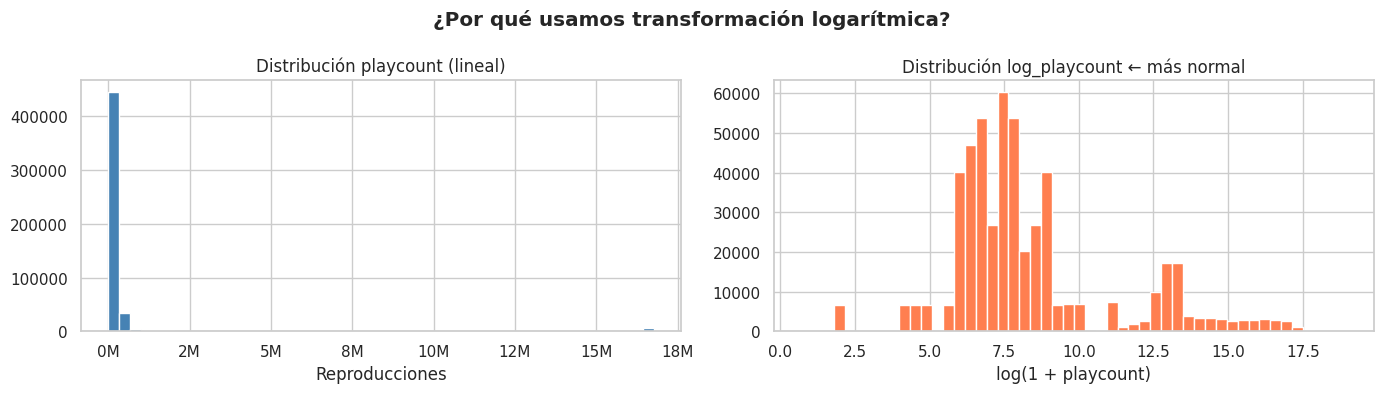

Skewness playcount:     13.11
Skewness log_playcount: 1.11


In [74]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

p99 = df_clean['playcount'].quantile(0.99)

axes[0].hist(df_clean['playcount'].clip(upper=p99), bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Distribución playcount (lineal)')
axes[0].set_xlabel('Reproducciones')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))

axes[1].hist(df_clean['log_playcount'], bins=50, color='coral', edgecolor='white')
axes[1].set_title('Distribución log_playcount ← más normal')
axes[1].set_xlabel('log(1 + playcount)')

plt.suptitle('¿Por qué usamos transformación logarítmica?', fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Skewness playcount:     {df_clean["playcount"].skew():.2f}')
print(f'Skewness log_playcount: {df_clean["log_playcount"].skew():.2f}')

### Distribución de duration_min con boxplot

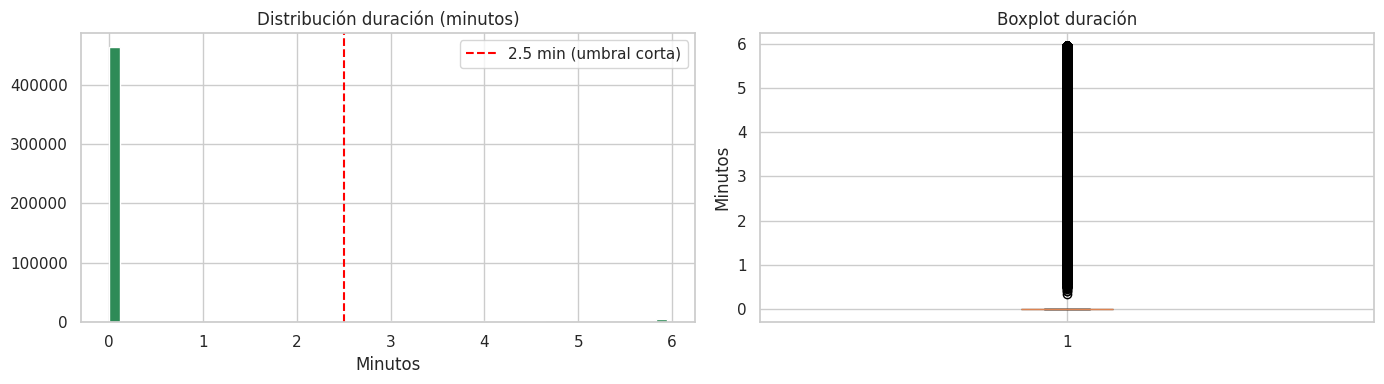

Media duración: 0.40 min
Canciones cortas (<2.5 min): 467,611 (91.3%)


In [75]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

dur_ok   = df_clean['duration_min'].dropna()
dur_clip = dur_ok.clip(upper=dur_ok.quantile(0.99))

axes[0].hist(dur_clip, bins=50, color='seagreen', edgecolor='white')
axes[0].set_title('Distribución duración (minutos)')
axes[0].set_xlabel('Minutos')
axes[0].axvline(2.5, color='red', linestyle='--', label='2.5 min (umbral corta)')
axes[0].legend()

axes[1].boxplot(dur_clip, vert=True, patch_artist=True,
                boxprops=dict(facecolor='seagreen', alpha=0.5))
axes[1].set_title('Boxplot duración')
axes[1].set_ylabel('Minutos')

plt.tight_layout()
plt.show()

print(f'Media duración: {dur_ok.mean():.2f} min')
print(f'Canciones cortas (<2.5 min): {(dur_ok < 2.5).sum():,} ({(dur_ok < 2.5).mean()*100:.1f}%)')

### Top 15 artistas (código original mantenido, ahora con df_clean correcto)

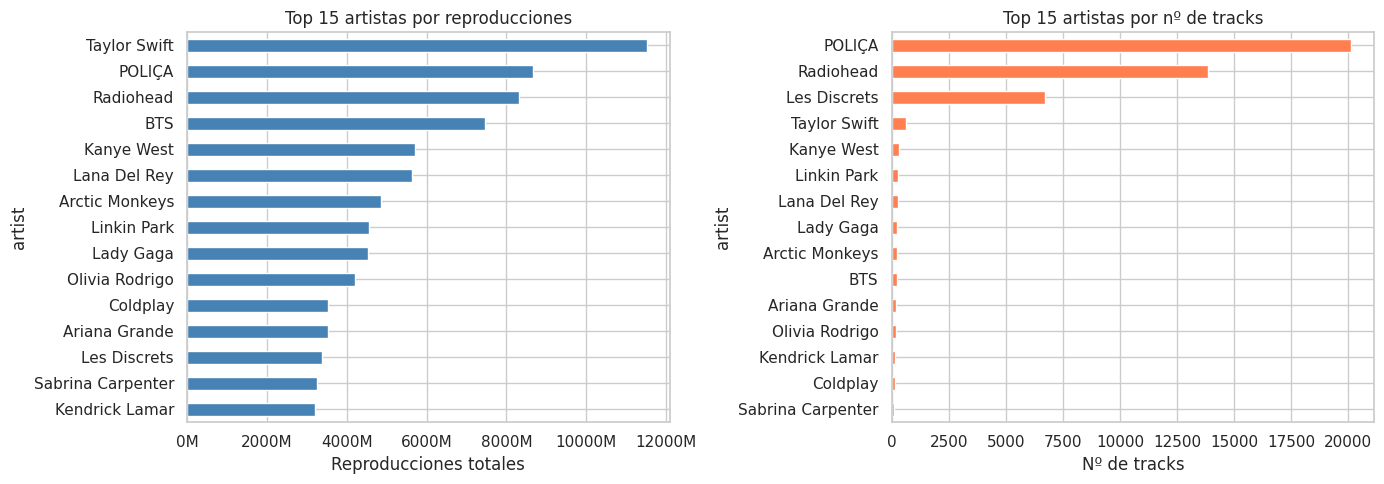

Top 5 artistas concentran 14.5% de reproducciones


In [76]:
top_artists = (
    df_clean
    .groupby('artist')[['playcount', 'name']]
    .agg({'playcount': 'sum', 'name': 'count'})
    .rename(columns={'playcount': 'total_plays', 'name': 'n_tracks'})
    .sort_values('total_plays', ascending=False)
    .head(15)
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

top_artists.sort_values('total_plays').plot.barh(
    y='total_plays', ax=axes[0], color='steelblue', legend=False
)
axes[0].set_title('Top 15 artistas por reproducciones')
axes[0].set_xlabel('Reproducciones totales')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))

top_artists.sort_values('n_tracks').plot.barh(
    y='n_tracks', ax=axes[1], color='coral', legend=False
)
axes[1].set_title('Top 15 artistas por nº de tracks')
axes[1].set_xlabel('Nº de tracks')

plt.tight_layout()
plt.show()

top5_share = top_artists['total_plays'].head(5).sum() / df_clean['playcount'].sum() * 100
print(f'Top 5 artistas concentran {top5_share:.1f}% de reproducciones')

### Análisis por tag (género) — solo tracks con tag asignado --> No funciona

In [77]:
df_con_tag = df_clean.dropna(subset=['tag']).copy()

if len(df_con_tag) > 0:
    stats_tag = (
        df_con_tag
        .groupby('tag')
        .agg(
            n_tracks        =('name', 'count'),
            plays_medio     =('playcount', 'mean'),
            plays_total     =('playcount', 'sum'),
            engagement_medio=('playcount_per_listener', 'mean'),
        )
        .reset_index()
    )
    top10_tag = stats_tag.sort_values('plays_total', ascending=False).head(10)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].barh(top10_tag['tag'], top10_tag['plays_total'] / 1e6,
                 color=sns.color_palette('Blues_r', 10))
    axes[0].invert_yaxis()
    axes[0].set_title('Top 10 tags por reproducciones totales')
    axes[0].set_xlabel('Millones')

    axes[1].barh(top10_tag['tag'], top10_tag['n_tracks'],
                 color=sns.color_palette('Oranges_r', 10))
    axes[1].invert_yaxis()
    axes[1].set_title('Top 10 tags por nº de tracks')
    axes[1].set_xlabel('Nº de tracks')

    plt.tight_layout()
    plt.show()
else:
    print('⚠️  No hay tracks con tag para analizar.')

⚠️  No hay tracks con tag para analizar.


### Análisis geográfico — excluimos GLOBAL y UNKNOWN para este análisis

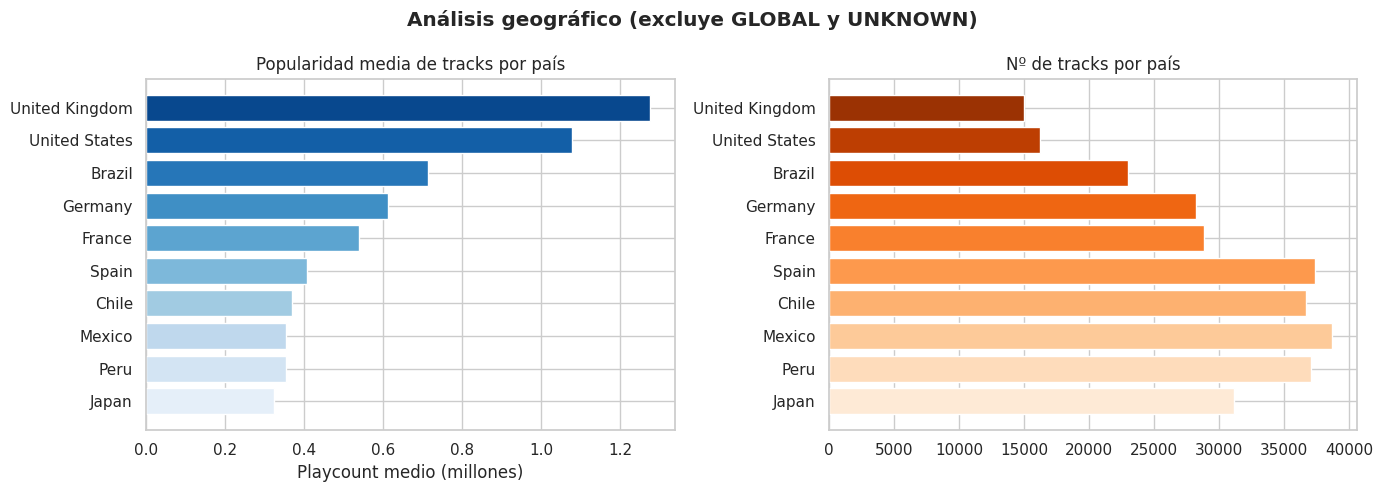

In [78]:
df_geo = df_clean[~df_clean['country'].isin(['UNKNOWN', 'GLOBAL'])].dropna(subset=['country'])

if len(df_geo) > 0:
    stats_pais = (
        df_geo
        .groupby('country')
        .agg(
            n_tracks       =('name', 'count'),
            plays_medio    =('playcount', 'mean'),
            engagement_medio=('playcount_per_listener', 'mean'),
        )
        .sort_values('plays_medio', ascending=False)
        .reset_index()
    )

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].barh(stats_pais['country'], stats_pais['plays_medio'] / 1e6,
                 color=sns.color_palette('Blues_r', len(stats_pais)))
    axes[0].invert_yaxis()
    axes[0].set_title('Popularidad media de tracks por país')
    axes[0].set_xlabel('Playcount medio (millones)')

    axes[1].barh(stats_pais['country'], stats_pais['n_tracks'],
                 color=sns.color_palette('Oranges_r', len(stats_pais)))
    axes[1].invert_yaxis()
    axes[1].set_title('Nº de tracks por país')

    plt.suptitle('Análisis geográfico (excluye GLOBAL y UNKNOWN)', fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print('ℹ️  Pocos tracks con país asignado en df_merged. El análisis geográfico es limitado.')
    print('   Para enriquecer: aumentar las páginas en geo.getTopTracks en el pipeline.')

### Distribución de playcount por is_hit e is_short_track

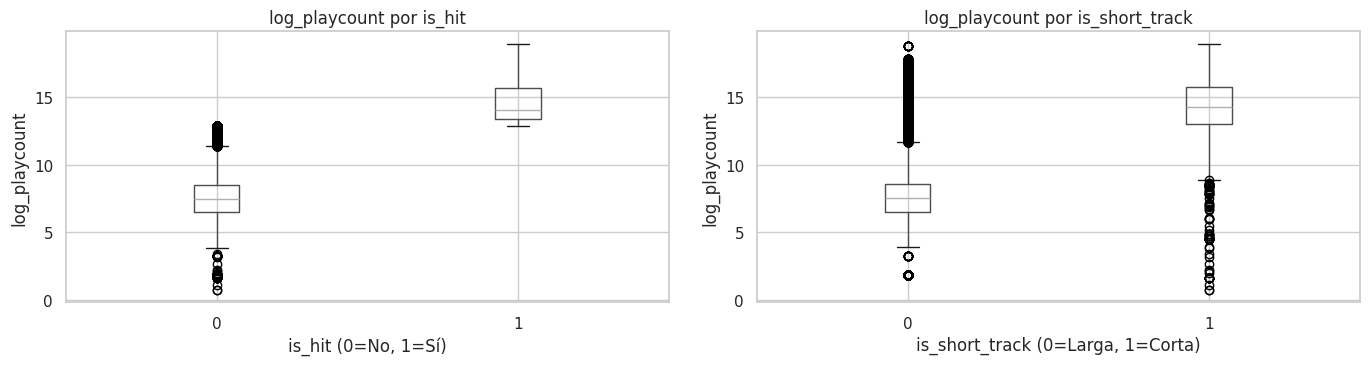

In [79]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

df_clean.boxplot(column='log_playcount', by='is_hit', ax=axes[0])
axes[0].set_xlabel('is_hit (0=No, 1=Sí)')
axes[0].set_ylabel('log_playcount')
plt.sca(axes[0])
plt.title('log_playcount por is_hit')

df_clean.boxplot(column='log_playcount', by='is_short_track', ax=axes[1])
axes[1].set_xlabel('is_short_track (0=Larga, 1=Corta)')
axes[1].set_ylabel('log_playcount')
plt.sca(axes[1])
plt.title('log_playcount por is_short_track')

plt.suptitle('')
plt.tight_layout()
plt.show()

---
## 9. Correlaciones

### Spearman entre duration_min y playcount (código original mantenido)

In [80]:
idx = df_clean[['duration_min', 'playcount']].dropna().index
rho, p = spearmanr(df_clean.loc[idx, 'duration_min'], df_clean.loc[idx, 'playcount'])

print(f'Spearman duration_min vs playcount: ρ={rho:.3f}, p={p:.4f}')
print(f'Interpretación: {"significativo" if p < 0.05 else "no significativo"} (α=0.05)')

Spearman duration_min vs playcount: ρ=0.484, p=0.0000
Interpretación: significativo (α=0.05)


### Heatmap de correlaciones de Spearman

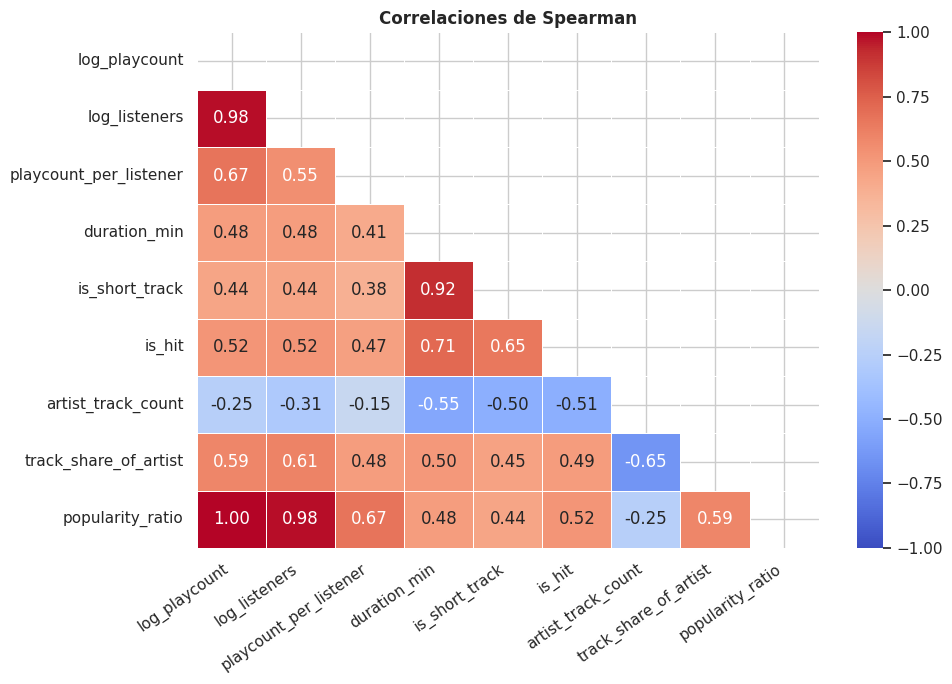

Variables más correlacionadas con log_playcount:
  + popularity_ratio: ρ=1.000
  + log_listeners: ρ=0.979
  + playcount_per_listener: ρ=0.669
  + track_share_of_artist: ρ=0.593


In [81]:
cols_posibles = [
    'log_playcount', 'log_listeners', 'playcount_per_listener',
    'duration_min', 'is_short_track', 'is_hit',
    'artist_track_count', 'track_share_of_artist', 'popularity_ratio'
]
cols_numericas = [c for c in cols_posibles if c in df_clean.columns]

corr = df_clean[cols_numericas].corr(method='spearman')

fig, ax = plt.subplots(figsize=(10, 7))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, vmin=-1, vmax=1, linewidths=0.5, ax=ax)
ax.set_title('Correlaciones de Spearman', fontweight='bold')
plt.xticks(rotation=35, ha='right')
plt.tight_layout()
plt.show()

if 'log_playcount' in corr.columns:
    corr_target = corr['log_playcount'].drop('log_playcount').abs().sort_values(ascending=False)
    print('Variables más correlacionadas con log_playcount:')
    for feat, r in corr_target.head(4).items():
        signo = '+' if corr.loc['log_playcount', feat] > 0 else '-'
        print(f'  {signo} {feat}: ρ={r:.3f}')

---
## 10. Tests estadísticos

### 1. Mann-Whitney U: canciones cortas vs largas (código original completado)


* H0: la distribución de playcount es igual entre tracks cortos y largos

In [82]:
short = df_clean[df_clean['is_short_track'] == 1]['playcount'].dropna()
long  = df_clean[df_clean['is_short_track'] == 0]['playcount'].dropna()

stat_mw, p_mw = mannwhitneyu(short, long, alternative='two-sided')

print('=== Mann-Whitney U: cortas vs largas ===')
print(f'  U: {stat_mw:.2f} | p-valor: {p_mw:.6f}')
print(f'  → {"se rechaza H0" if p_mw < 0.05 else "no se rechaza H0"} (α=0.05)')
if p_mw < 0.05:
    mas_popular = 'cortas' if short.median() > long.median() else 'largas'
    print(f'  → Las canciones {mas_popular} tienen mayor playcount mediano.')
    print(f'     Mediana cortas: {short.median():,.0f} | Mediana largas: {long.median():,.0f}')

=== Mann-Whitney U: cortas vs largas ===
  U: 18298856482.00 | p-valor: 0.000000
  → se rechaza H0 (α=0.05)
  → Las canciones cortas tienen mayor playcount mediano.
     Mediana cortas: 1,572,758 | Mediana largas: 1,791


### 2. Kruskal-Wallis: diferencias por género (tag) --> No funciona

* H0: la distribución de playcount es igual en todos los géneros

In [83]:
df_con_tag_kw = df_clean.dropna(subset=['tag', 'playcount'])

# Solo tags con al menos 5 tracks (grupos muy pequeños no son estadísticamente fiables)
tags_validos = df_con_tag_kw['tag'].value_counts()
tags_validos = tags_validos[tags_validos >= 5].index.tolist()

grupos = [
    df_con_tag_kw[df_con_tag_kw['tag'] == tag]['playcount'].values
    for tag in tags_validos
]

if len(grupos) >= 2:
    stat_kw, p_kw = kruskal(*grupos)
    print('=== Kruskal-Wallis: diferencias por tag/género ===')
    print(f'  Géneros con ≥5 tracks: {len(grupos)}')
    print(f'  H: {stat_kw:.2f} | p-valor: {p_kw:.6f}')
    print(f'  → {"se rechaza H0" if p_kw < 0.05 else "no se rechaza H0"} (α=0.05)')
    if p_kw < 0.05:
        print('  → Hay diferencias significativas de popularidad entre géneros.')
else:
    print('⚠️  Insuficientes grupos para Kruskal-Wallis.')

⚠️  Insuficientes grupos para Kruskal-Wallis.


### 3. Análisis visual de duración por rangos (código original completado) 

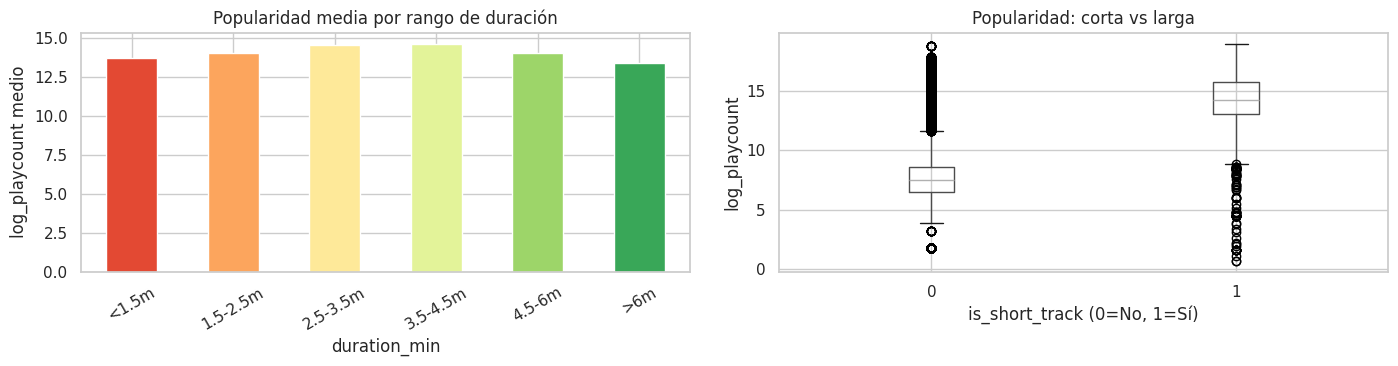

In [84]:
rangos = pd.cut(
    df_clean['duration_min'],
    bins=[0, 1.5, 2.5, 3.5, 4.5, 6, 100],
    labels=['<1.5m', '1.5-2.5m', '2.5-3.5m', '3.5-4.5m', '4.5-6m', '>6m']
)
pop_por_rango = df_clean.groupby(rangos, observed=True)['log_playcount'].mean()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

pop_por_rango.plot.bar(ax=axes[0], color=sns.color_palette('RdYlGn', 6))
axes[0].set_title('Popularidad media por rango de duración')
axes[0].set_ylabel('log_playcount medio')
axes[0].tick_params(axis='x', rotation=30)

df_clean.boxplot(column='log_playcount', by='is_short_track', ax=axes[1])
axes[1].set_xlabel('is_short_track (0=No, 1=Sí)')
axes[1].set_ylabel('log_playcount')
plt.sca(axes[1])
plt.title('Popularidad: corta vs larga')

plt.suptitle('')
plt.tight_layout()
plt.show()

---
## 11. Modelado



### 1. Regresión OLS explicativa sobre `log_playcount`

* Variables explicativas: duration_min y playcount_per_listener

In [86]:
import statsmodels.api as sm
df_model = df_clean[['log_playcount', 'duration_min', 'playcount_per_listener']].dropna()

X_ols = df_model[['duration_min', 'playcount_per_listener']]
X_ols = sm.add_constant(X_ols)
y_ols = df_model['log_playcount']

model_ols = sm.OLS(y_ols, X_ols).fit()
print(model_ols.summary())

                            OLS Regression Results                            
Dep. Variable:          log_playcount   R-squared:                       0.520
Model:                            OLS   Adj. R-squared:                  0.520
Method:                 Least Squares   F-statistic:                 2.777e+05
Date:                Fri, 03 Apr 2026   Prob (F-statistic):               0.00
Time:                        13:04:54   Log-Likelihood:            -1.0635e+06
No. Observations:              511962   AIC:                         2.127e+06
Df Residuals:                  511959   BIC:                         2.127e+06
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
const                      6

### 2. Random Forest — Clasificación y Regresión

In [87]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, r2_score, mean_absolute_error
from xgboost import XGBClassifier

### Preparar features para ML

#### Definición X e y

In [88]:
df_ml = df_clean.copy()
le_tag = LabelEncoder()
df_ml['tag_encoded'] = le_tag.fit_transform(df_ml['tag'].fillna('unknown'))


* FEATURES: columnas que usamos para predecir

In [89]:
FEATURES = [
    'log_listeners',           # oyentes en log (mejor predictor de popularidad)
    'duration_min',            # duración en minutos
    'is_short_track',          # formato corto (<2.5 min)
    'tag_encoded',             # género
    'artist_track_count',      # cuántos tracks tiene el artista
    'track_share_of_artist',   # peso de este track en el catálogo del artista
    'playcount_per_listener',  # engagement
]
FEATURES = [f for f in FEATURES if f in df_ml.columns]


* y para clasificación: is_hit (0 o 1)
* y para regresión:     log_playcount (continuo)

In [90]:
df_ml_ok = df_ml[FEATURES + ['log_playcount', 'is_hit']].dropna()

X = df_ml_ok[FEATURES]
y_clf = df_ml_ok['is_hit']
y_reg = df_ml_ok['log_playcount']

print(f'Dataset ML: {len(df_ml_ok):,} filas | {len(FEATURES)} features')
print(f'Features: {FEATURES}')
print(f'Hits: {y_clf.sum():,} ({y_clf.mean()*100:.0f}%)')

Dataset ML: 511,961 filas | 7 features
Features: ['log_listeners', 'duration_min', 'is_short_track', 'tag_encoded', 'artist_track_count', 'track_share_of_artist', 'playcount_per_listener']
Hits: 51,197 (10%)


#### Train / Test split — stratify para conservar proporción de hits

In [91]:
X_train, X_test, y_clf_train, y_clf_test = train_test_split(
    X, y_clf, test_size=0.2, random_state=42, stratify=y_clf
)
_, _, y_reg_train, y_reg_test = train_test_split(
    X, y_reg, test_size=0.2, random_state=42
)

print(f'Train: {len(X_train):,} | Test: {len(X_test):,}')

Train: 409,568 | Test: 102,393


### Clasificación: ¿es un hit? (is_hit)

In [92]:
rf_clf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_clf.fit(X_train, y_clf_train)
y_pred_clf = rf_clf.predict(X_test)

print('=== Clasificación (is_hit) ===')
print(classification_report(y_clf_test, y_pred_clf, target_names=['No hit', 'Hit']))

=== Clasificación (is_hit) ===
              precision    recall  f1-score   support

      No hit       1.00      1.00      1.00     92154
         Hit       1.00      1.00      1.00     10239

    accuracy                           1.00    102393
   macro avg       1.00      1.00      1.00    102393
weighted avg       1.00      1.00      1.00    102393



### Regresión: predecir log_playcount

In [93]:
rf_reg = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_reg.fit(X_train, y_reg_train)
y_pred_reg = rf_reg.predict(X_test)

print('=== Regresión (log_playcount) ===')
print(f'R²:  {r2_score(y_reg_test, y_pred_reg):.3f}')
print(f'MAE: {mean_absolute_error(y_reg_test, y_pred_reg):.3f}')

=== Regresión (log_playcount) ===
R²:  -0.014
MAE: 2.062


### Feature importance (código original completado)

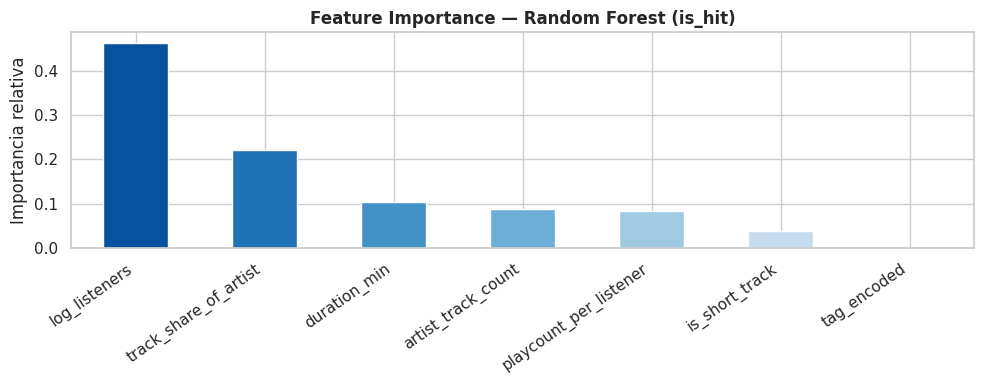

Las 3 variables más importantes:
  → log_listeners: 46.4%
  → track_share_of_artist: 22.2%
  → duration_min: 10.3%


In [94]:
importancias = pd.Series(
    rf_clf.feature_importances_, index=FEATURES
).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 4))
importancias.plot.bar(ax=ax, color=sns.color_palette('Blues_r', len(importancias)))
ax.set_title('Feature Importance — Random Forest (is_hit)', fontweight='bold')
ax.set_ylabel('Importancia relativa')
plt.xticks(rotation=35, ha='right')
plt.tight_layout()
plt.show()

print('Las 3 variables más importantes:')
for feat, val in importancias.head(3).items():
    print(f'  → {feat}: {val*100:.1f}%')

### Función de predicción final 

In [95]:
def predecir_hit(nombre, artista, duracion_min, genero, oyentes_estimados):
    """Predice la probabilidad de que una canción sea un hit."""
    genero_enc = le_tag.transform([genero])[0] if genero in le_tag.classes_ else 0

    datos = pd.DataFrame([{
        'log_listeners'          : np.log1p(oyentes_estimados),
        'duration_min'           : duracion_min,
        'is_short_track'         : int(duracion_min < 2.5),
        'tag_encoded'            : genero_enc,
        'artist_track_count'     : 1,
        'track_share_of_artist'  : 1.0,
        'playcount_per_listener' : 5.0,
    }])
    datos = datos[FEATURES]

    prob = rf_clf.predict_proba(datos)[0][1] * 100
    clasificacion = '🚀 Hit potencial' if prob >= 70 else ('🟡 Potencial medio' if prob >= 45 else '📉 Bajo potencial')

    print('=' * 50)
    print(f'  🎵 {nombre} — {artista}')
    print('=' * 50)
    print(f'  Probabilidad de hit: {prob:.1f}%')
    print(f'  Clasificación:       {clasificacion}')
    print(f'  Género:              {genero}')
    print(f'  Duración:            {duracion_min:.1f} min{" (corta ⏱️)" if duracion_min < 2.5 else ""}')
    print('=' * 50)
    return prob

predecir_hit('Mi Canción', 'Mi Artista', 3.2, 'rock', 50000)

  🎵 Mi Canción — Mi Artista
  Probabilidad de hit: 0.0%
  Clasificación:       📉 Bajo potencial
  Género:              rock
  Duración:            3.2 min


np.float64(0.0)

---
## 12. Conclusiones

| Análisis | Qué evaluar |
|---|---|
| Distribución playcount | Muy sesgada → necesaria transformación log |
| Mann-Whitney | p < 0.05 → hay diferencia real de popularidad entre cortas y largas |
| Kruskal-Wallis | p < 0.05 → el género influye en la popularidad |
| Spearman | Signo de ρ → si negativo, canciones cortas son más populares |
| Random Forest (clf) | Ver F1 en clase 'Hit'. F1 > 0.7 es aceptable |
| Feature importance | `log_listeners` suele ser el predictor dominante |

### Limitaciones
- `df_merged` hereda las limitaciones de ambas fuentes: tags solo en ~10% de tracks, country con mucha presencia de GLOBAL/UNKNOWN.
- `published` en `backup_tracks` es la fecha de adición al catálogo de Last.fm, no la fecha de lanzamiento original.
- `lastfm_dataset` aporta country y genre_tag, pero la cobertura de mbid compartidos con backup_tracks es parcial.

# Función de predicción final Streamlit <a id='6'></a>

Esta función es el **output de negocio** del módulo:  
> "Tu canción tiene X% de probabilidad de ser un hit"

**Para usar en Streamlit:** esta función puede llamarse directamente desde la app.

In [96]:
# ── CORRECCIÓN: predecir_hit para Streamlit ──────────────────────────────────
# La versión anterior usaba variables que no existen en este notebook:
#   le_genero, le_pais, genre_encoded, country_encoded,
#   listeners_log, n_tracks_artista, peso_en_artista, engagement
# Todas esas son de una versión antigua. En este notebook el encoder
# se llama le_tag y las features usan los nombres de la celda 175 (FEATURES).
#
# Esta versión es coherente con el modelo entrenado en celdas 173-183.

def predecir_hit(nombre, artista, duracion_min, genero, oyentes_estimados, pais=None):
    """
    Predice la probabilidad de que una canción sea un hit.

    Parámetros:
        nombre            — nombre de la canción
        artista           — nombre del artista
        duracion_min      — duración en minutos (ej: 3.5)
        genero            — género musical: debe ser un tag de Last.fm (ej: 'rock', 'pop')
        oyentes_estimados — estimación de oyentes únicos
        pais              — informativo, no afecta la predicción (el modelo no tiene país)

    Devuelve: probabilidad de hit (0-100%)
    """
    # Encoding del género con le_tag — el mismo encoder usado en el entrenamiento
    genero_enc = le_tag.transform([genero])[0] if genero in le_tag.classes_ else 0

    # Vector de features — mismo orden y nombres exactos que en FEATURES (celda 175)
    datos = pd.DataFrame([{
        'log_listeners'          : np.log1p(oyentes_estimados),
        'duration_min'           : duracion_min,
        'is_short_track'         : int(duracion_min < 2.5),
        'tag_encoded'            : genero_enc,
        'artist_track_count'     : 1,    # artista nuevo: 1 track
        'track_share_of_artist'  : 1.0,  # único track del artista
        'playcount_per_listener' : 5.0,  # engagement inicial estimado
    }])
    datos = datos[FEATURES]  # mismo orden que durante el entrenamiento

    probabilidad = rf_clf.predict_proba(datos)[0][1] * 100

    if probabilidad >= 70:
        clasificacion = '🚀 Hit potencial'
    elif probabilidad >= 45:
        clasificacion = '🟡 Potencial medio'
    else:
        clasificacion = '📉 Bajo potencial'

    print('=' * 50)
    print(f'  🎵 {nombre} — {artista}')
    print('=' * 50)
    print(f'  Probabilidad de hit:  {probabilidad:.1f}%')
    print(f'  Clasificación:        {clasificacion}')
    print(f'  Género:               {genero}')
    if pais:
        print(f'  País:                 {pais}  (solo informativo)')
    print(f'  Duración:             {duracion_min:.1f} min', end='')
    print(' (corta ⏱️)' if duracion_min < 2.5 else '')
    print('=' * 50)
    return probabilidad


# Ejemplo de uso
predecir_hit(
    nombre='Mi Canción',
    artista='Mi Artista',
    duracion_min=2.3,
    genero='pop',
    oyentes_estimados=50000,
    pais='spain'
)


NameError: name 'le_genero' is not defined


# 💡 Ideas para Streamlit / App web



Con lo que tienes, puedes construir una app con estas secciones:



### Página 1 — Predictor de hit


```python
# En app.py:
import streamlit as st
import pickle


* Cargar modelo y encoders guardados

In [103]:


rf_clf = pickle.load(open('modelo_hits.pkl', 'rb'))
le_genero = pickle.load(open('le_genero.pkl', 'rb'))

st.title('🎵 ¿Será un hit?')
duracion   = st.slider('Duración (min)', 1.0, 8.0, 3.5)
genero     = st.selectbox('Género', ['pop', 'rock', 'hip-hop', 'electronic'])
oyentes    = st.number_input('Oyentes estimados', value=10000)

if st.button('Predecir'):
    prob = predecir_hit('Mi canción', 'Mi artista', duracion, genero, 'spain', oyentes)
    st.metric('Probabilidad de hit', f'{prob:.0f}%')
    st.progress(prob / 100)


FileNotFoundError: [Errno 2] No such file or directory: 'modelo_hits.pkl'


### Página 2 — Dashboard del mercado


- Top 15 canciones (barplot)
- Géneros por popularidad (barplot)
- Mapa de calor géneros × países



### Página 3 — Explorador de artistas


- Input: nombre del artista
- Output: sus tracks en el dataset, popularidad media, géneros



### Cómo guardar y cargar el modelo


In [102]:
# ── CORRECCIÓN: este bloque guardaba le_genero y le_pais que no existen ─────
# En este notebook el encoder de género se llama le_tag (creado en celda 173).
# le_genero y le_pais son de una versión antigua del notebook.
# Guardarlos aquí causaba NameError. Este bloque queda como referencia comentada.

# import pickle
# pickle.dump(rf_clf,    open('models/modelo_hits.pkl', 'wb'))   # ← usar celda 209
# pickle.dump(le_genero, open('models/le_genero.pkl', 'wb'))     # ← no existe
# pickle.dump(le_pais,   open('models/le_pais.pkl', 'wb'))       # ← no existe

print('ℹ️  Este bloque ha sido reemplazado por el guardado correcto en la sección 12 (celda 209).')
print('   Ejecuta la celda del bloque de guardado al final del notebook.')


NameError: name 'le_genero' is not defined


### Ideas de ML adicionales con las variables actuales



| Idea | Variables necesarias | Factibilidad |
|---|---|---|
| Predecir si un track será hit | listeners, genre, country, duration | ✅ Ya tienes esto |
| Clustering de géneros musicales | playcount, engagement, pct_cortas | ✅ KMeans con tus datos |
| Ranking de países con más potencial | plays_medio por país | ✅ Con geo.getTopTracks |
| Detectar artistas emergentes | n_tracks_artista, plays_medio, tendencia | ✅ Con datos temporales |
| Predecir viralidad por duración | is_short_track + playcount | ✅ Ya tienes esto |
| Audio features (danceability, BPM...) | — | ❌ Necesitas Spotify API |



### Para el backup_tracks.csv (tiene 'published' = fechas reales)


El archivo `backup_tracks.csv` tiene un campo `published` con fechas reales de publicación.  
Esto permite análisis temporales reales: qué géneros triunfan en verano, tendencias por año, etc.


# Guardado de modelos

##  Guardar modelos para usar en Streamlit 


In [101]:
import joblib
import os

os.makedirs('models', exist_ok=True)

# ── Verificación antes de guardar ────────────────────────────────────────────
# Comprobar que el modelo y el encoder son coherentes entre sí.
# Si este assert falla, vuelve a ejecutar las celdas 173-183 antes de guardar.
assert rf_clf.n_features_in_ == len(FEATURES), (
    f'ERROR: el modelo espera {rf_clf.n_features_in_} features pero FEATURES tiene {len(FEATURES)}. '
    'Vuelve a ejecutar las celdas 173-183.'
)
print('✅ Verificación OK: modelo y FEATURES son coherentes')
print(f'   Features: {FEATURES}')
print(f'   Géneros disponibles: {len(le_tag.classes_)}')
print()

# Clasificador — pocos MB, se puede subir a GitHub
joblib.dump(rf_clf,  'models/modelo_hits_clf.pkl')
print(f'modelo_hits_clf.pkl  → {os.path.getsize("models/modelo_hits_clf.pkl")/1e6:.1f} MB  ✅')

# Regresor — puede pesar ~260MB. Se guarda con compresión.
# ⚠️  Añadir al .gitignore: models/modelo_plays_reg.pkl
joblib.dump(rf_reg,  'models/modelo_plays_reg.pkl', compress=3)
print(f'modelo_plays_reg.pkl → {os.path.getsize("models/modelo_plays_reg.pkl")/1e6:.1f} MB  ⚠️  excluir de Git')

# Encoder de género — le_tag (NO le_genero, que no existe en este notebook)
joblib.dump(le_tag,  'models/le_tag.pkl')
print(f'le_tag.pkl           → {os.path.getsize("models/le_tag.pkl")/1e3:.1f} KB  ✅')

# Lista de features — el orden es crítico: debe coincidir al cargar en Streamlit
with open('models/features.txt', 'w') as f:
    f.write('\n'.join(FEATURES))

print()
print('✅ Modelos guardados en /models/')
print('   Para cargarlos en Streamlit:')
print('   rf_clf = joblib.load("models/modelo_hits_clf.pkl")')
print('   le_tag = joblib.load("models/le_tag.pkl")')


NameError: name 'le_genero' is not defined


## Guardar también las features usadas (importante: el orden debe coincidir)


In [100]:
with open('models/features.txt', 'w') as f:
    f.write('\n'.join(FEATURES))

print('✅ Modelos guardados en /models/')
print('   Para cargarlos en Streamlit:')
print('   rf_clf = pickle.load(open("models/modelo_hits_clf.pkl", "rb"))')

✅ Modelos guardados en /models/
   Para cargarlos en Streamlit:
   rf_clf = pickle.load(open("models/modelo_hits_clf.pkl", "rb"))
